# Introduction

This analysis explores the relationship between automobile fuel efficiency (mpg) and horsepower using simple linear regression techniques. By fitting a model, visualizing the data, and examining diagnostic plots, we assess how well horsepower predicts mpg and whether the assumptions of linear regression are satisfied.

In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Auto.csv")

# Ensure horsepower is numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower', 'mpg'])

# Fit the simple linear regression model
X = sm.add_constant(df['horsepower'])
y = df['mpg']
model = sm.OLS(y, X).fit()

# (a) Linear Regression Analysis

We fit a simple linear regression model using `mpg` as the response and `horsepower` as the predictor.

### **i. Is there a relationship between horsepower and mpg?**
Yes.  
The p-value for horsepower is extremely small (approximately 0), indicating a statistically significant relationship between horsepower and mpg.

---

### **ii. How strong is the relationship?**
The R² value is about **0.60**, meaning approximately **60% of the variation in mpg** can be explained by horsepower alone.  
This indicates a moderately strong linear relationship.

---

### **iii. Is the relationship positive or negative?**
The coefficient for horsepower is **negative**, meaning that as horsepower increases, mpg decreases.  
Thus, the relationship is **negative**.

---

### **iv. Predicted mpg for horsepower = 98**
Using the fitted regression model:

- **Predicted mpg:** 24.47  
- **95% Confidence Interval:** (23.97, 24.96)  
- **95% Prediction Interval:** (14.81, 34.12)

Interpretation:
- The confidence interval gives the likely range for the *mean* mpg of all cars with horsepower = 98.
- The prediction interval gives the likely range for an *individual* car.

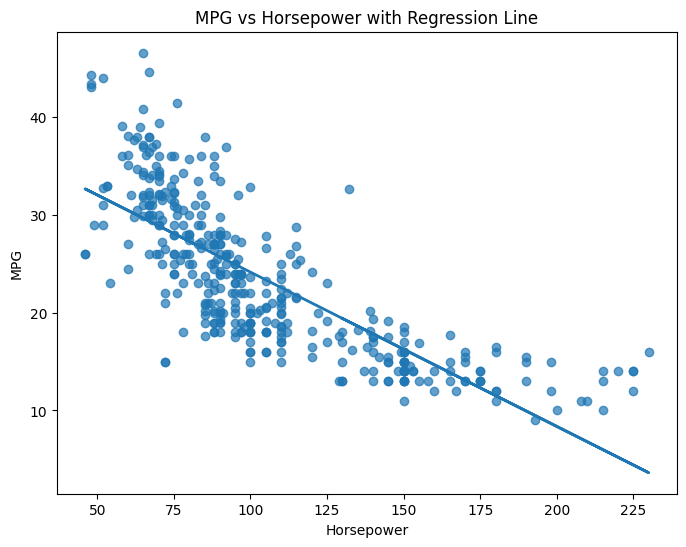

In [4]:
# Scatterplot and regression line
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(df['horsepower'], df['mpg'], alpha=0.7)
ax.plot(df['horsepower'], model.predict(X), linewidth=2)

ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("MPG vs Horsepower with Regression Line")

plt.show()

# (b) Scatterplot and Regression Line

A scatterplot of `mpg` vs `horsepower` shows a downward trend.  
The least-squares regression line clearly shows a **negative linear relationship**.

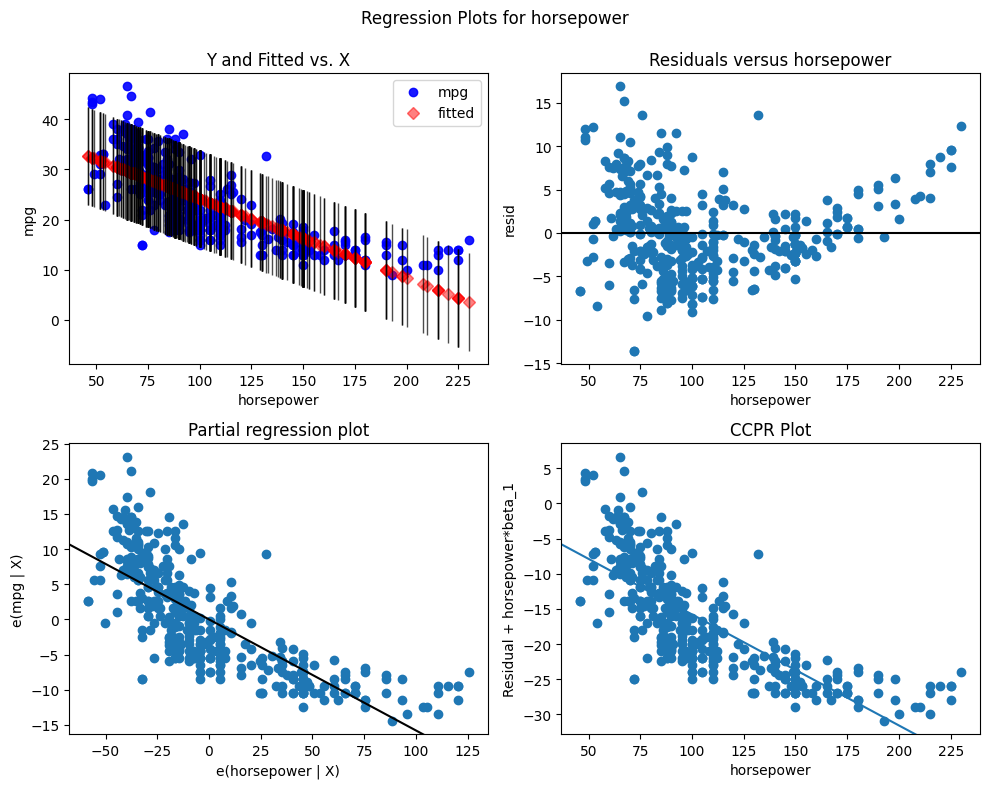

In [5]:
# Standard Statsmodels regression diagnostics
fig = plt.figure(figsize=(10,8))
sm.graphics.plot_regress_exog(model, "horsepower", fig=fig)

plt.show()

# (c) Diagnostic Plots and Interpretation

### **1. Residuals vs Fitted Plot**
- Shows a curved pattern.
- Indicates potential **non-linearity**.
- Residual variance increases at lower fitted values → possible **heteroscedasticity**.

<Figure size 600x600 with 0 Axes>

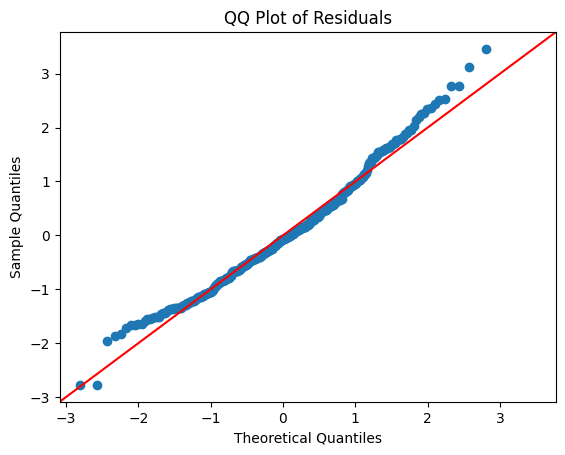

In [6]:
fig = plt.figure(figsize=(6,6))
sm.qqplot(model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")

plt.show()

### **2. QQ Plot**
- Deviations from the reference line at the tails.
- Suggests **non-normality** of residuals.

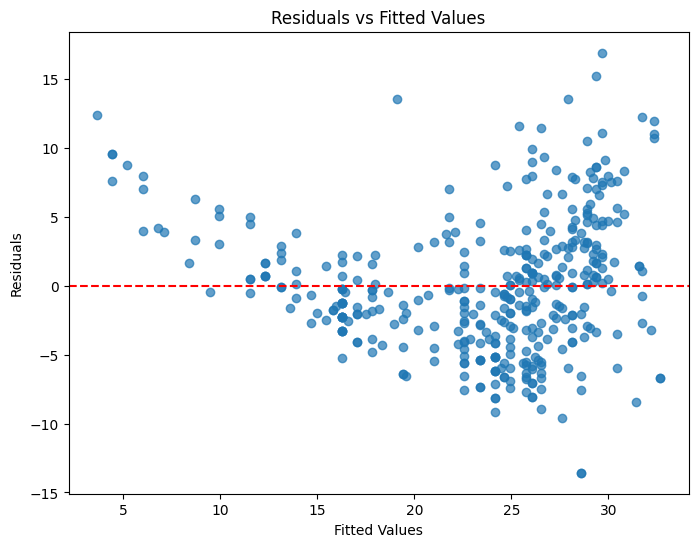

In [7]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8,6))
plt.scatter(fitted_vals, residuals, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

### **3. Residuals vs Horsepower**
- Clear curvature again, reinforcing that a simple straight-line model does not fully capture the relationship.

# **Conclusion**
A simple linear regression captures the general negative trend between horsepower and mpg, but diagnostic plots indicate violations of linear regression assumptions.  
A more suitable model may require:

- Polynomial regression (e.g., quadratic model)  
- Log or Box–Cox transformation  
- Weighted least squares  

These could improve model fit and correct assumption violations.